In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from tensorflow.python.distribute.single_loss_example import single_loss_example
from torch.distributed.fsdp.wrap import lambda_auto_wrap_policy

from epiuc.uncertainty.classification import LeNet_MNIST
from epiuc.uncertainty.wrapper import Ensemble_Classifier
from property_procedures.utils import ensemble_probs, total_uncertainty_ensemble, epistemic_uncertainty_ensemble, \
    aleatoric_uncertainty_ensemble

[INFO] Using Python-MIP package version 1.12.0 [model.py <module>]


/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from config import DATALOADER_CONFIGS, BACKEND


def load_mnist(vali_size=0.1, generator=None, loading_configs=DATALOADER_CONFIGS, ROOT_PATH="../data"):
    """
    Load MNIST dataset.
    See `load_image_data` for more details on the arguments.
    :return: MNIST trainloader, valloader, testloader
    """

    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize(mean=[0.1307], std=[0.3081])]
    )

    trainset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=True, download=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, **loading_configs
    )

    testset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=False, download=True, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=loading_configs["batch_size"],
        shuffle=False,
        num_workers=loading_configs["num_workers"],
        pin_memory=loading_configs["pin_memory"]
    )

    return trainloader, testloader

In [3]:
trainloader, testloader = load_mnist()

In [4]:
lenet_model = LeNet_MNIST(drop_prob=0.5, in_channels=1, image_width=28, image_heigth=28)
ensemble_lenet = Ensemble_Classifier(
    base_model=lenet_model,
    n_models=5,
    random_state=42
)
ensemble_lenet.load("../models/Ensemble_MNIST/")
ensemble_lenet.compile(backend=BACKEND)
ensemble_lenet.to(device=torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"))

Ensemble_Classifier()

# Train Ensemble of LeNet models

In [5]:
iter_test = iter(testloader)
all_test_images, all_test_labels = [], []
for image_batch, label_batch in iter_test:
    all_test_images.append(image_batch)
    all_test_labels.append(label_batch)
all_test_images = torch.cat(all_test_images, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)
all_test_images.shape

/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([10000, 1, 28, 28])

In [6]:
for idx, image in enumerate(all_test_images):
    if image.shape != (1, 28, 28):
        raise ValueError("Image shape is not correct. Expected (1, 28, 28), got {}".format(image.shape))
    prob = ensemble_lenet.predict(image.view(1, *image.shape))[0].max()
    if prob < 1:
        print("Image with low probability: ", prob.item())
        print("Image shape: ", image.shape)
        break

Image with low probability:  0.988794207572937
Image shape:  torch.Size([1, 28, 28])


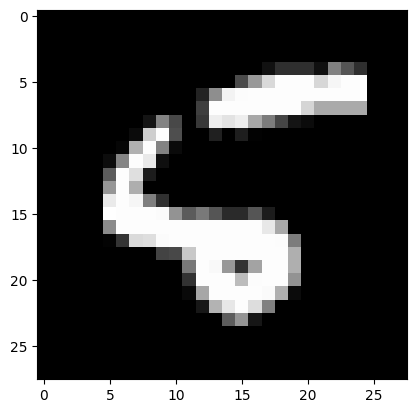

Label =  tensor(5)


In [7]:
# visualize the image
import matplotlib.pyplot as plt
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.show()
print("Label = ", all_test_labels[idx])

In [8]:
print(ensemble_lenet.predict(image.view(1, *image.shape),raw_output=False)[0])

tensor([[1.7199e-14, 1.0718e-16, 2.3986e-19, 3.8625e-16, 3.1982e-13, 9.8879e-01,
         1.1078e-02, 1.6478e-17, 1.2773e-04, 6.9556e-10]],
       grad_fn=<CatBackward0>)


In [9]:
from property_procedures import validity_loss_function, counter_factual_optimization_routine

point_of_interest = image.view(1, *image.shape)  # Reshape to (1, 1, 28, 28) for the model
DESIRED_CLASS = 6
MAX_STEPS = 5000
DELTA = 4
N_POINTS = 100
OPTIMIZER_LR = 1
PROB_WEIGHT = 1
LAMBDA_1 = 1
LAMBDA_2 = 1
PATIENCE = 250
DESIRED_VALIDITY = 0.9


counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=validity_loss_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

Patience limit reached.


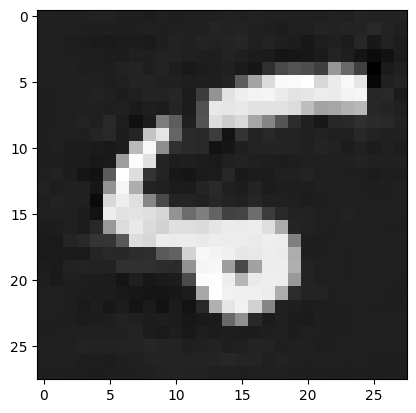

In [10]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


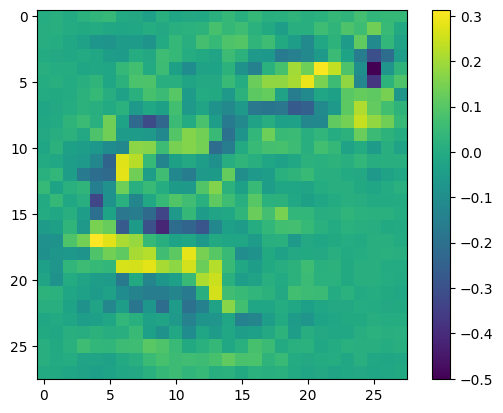

In [11]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [12]:
from property_procedures import discriminative_loss_function, counter_factual_optimization_routine

counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=discriminative_loss_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

Patience limit reached.


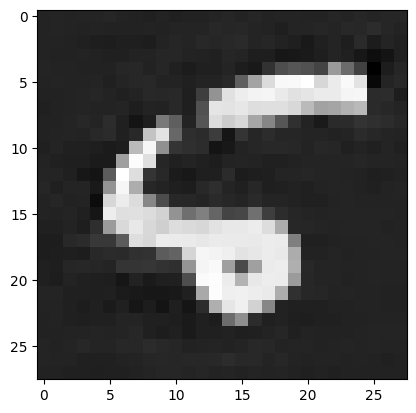

In [13]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


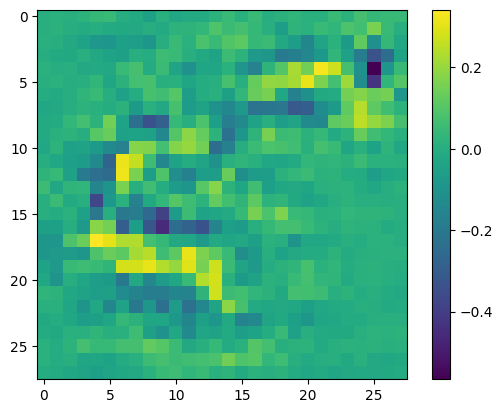

In [14]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [15]:
print(ensemble_lenet.predict(counter_factual, raw_output=False)[0])
print(ensemble_lenet.predict(counter_factual, raw_output=True)[1])

tensor([[2.2844e-11, 1.9370e-17, 1.1170e-20, 3.0773e-19, 4.6110e-13, 4.0000e-01,
         6.0000e-01, 3.2080e-20, 1.4802e-07, 1.3334e-11]],
       grad_fn=<CatBackward0>)
tensor([[2.9229e-01, 6.0609e-05, 2.9223e-01]], grad_fn=<CatBackward0>)


## Discriminative Loss Function 2

In [16]:
from property_procedures import discriminative_loss_function_2, counter_factual_optimization_routine

counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=discriminative_loss_function_2,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

Patience limit reached.


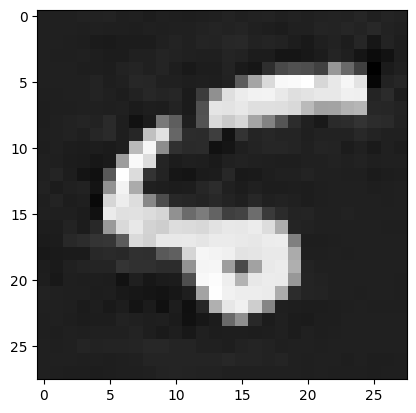

In [17]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


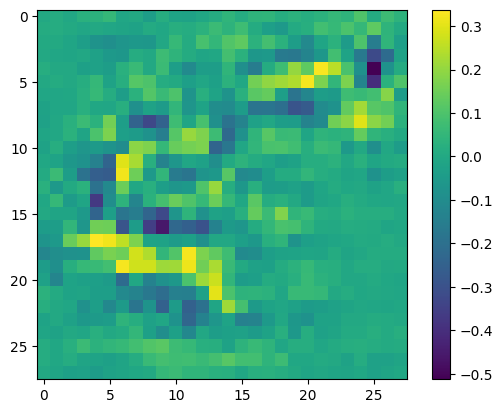

In [18]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [19]:
print(ensemble_lenet.predict(counter_factual, raw_output=False)[0])
print(ensemble_lenet.predict(counter_factual, raw_output=True)[1])

tensor([[3.1000e-11, 3.1380e-17, 1.7843e-20, 5.9766e-19, 1.3145e-12, 4.0000e-01,
         6.0000e-01, 4.7883e-20, 3.6017e-07, 3.5610e-11]],
       grad_fn=<CatBackward0>)
tensor([[2.9229e-01, 2.7137e-04, 2.9202e-01]], grad_fn=<CatBackward0>)
